# 图书评论情感分析：VADER 与 Transformers

本 notebook 对 `book_reviews_sample.csv` 中的英文图书评论完成以下流程：

1. 导入并检查数据；
2. 将评论转为小写并去除标点符号；
3. 使用 NLTK 的 `SentimentIntensityAnalyzer`（VADER）预测情感并可视化；
4. 使用 Transformers 预训练模型预测情感并可视化；
5. 对比人工评分、VADER 和 Transformers 的情感分布。

> 学习提示：按需求，两种模型都使用清洗后的文本。VADER 本身会利用感叹号、大小写等信号，因此去除标点和统一小写可能损失一部分情感强度信息；实际项目中可以同时测试原文与清洗文本。

## 1. 准备主要库与参数

NumPy 用于数值处理，Pandas 用于表格数据，VADER 提供词典式情感分析，Transformers 提供预训练神经网络模型。Matplotlib 与 Seaborn 用于结果可视化。

In [1]:
from pathlib import Path
import string

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline

# 固定主要参数，方便维护时统一修改。
CSV_FILENAME = "book_reviews_sample.csv"
TEXT_COLUMN = "reviewText"
RATING_COLUMN = "rating"
# 成熟的多语言 BERT 评论情感模型：输出 1–5 星，而不是只有正/负两类。
TRANSFORMER_MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
RANDOM_SEED = 42
TRANSFORMER_BATCH_SIZE = 16
TRANSFORMER_MAX_LENGTH = 512
VADER_NEGATIVE_THRESHOLD = -0.05
VADER_POSITIVE_THRESHOLD = 0.05
NEGATIVE_STAR_MAX = 2
POSITIVE_STAR_MIN = 4
np.random.seed(RANDOM_SEED)

# 使用明确且稳定的颜色，两个模型中的同一情感保持相同颜色。
SENTIMENT_ORDER = ["Negative", "Neutral", "Positive"]
SENTIMENT_COLORS = {
    "Negative": "#F59E0B",
    "Neutral": "#9CA3AF",
    "Positive": "#3B82F6",
}
sns.set_theme(style="whitegrid", context="notebook")

def star_to_sentiment(stars: int) -> str:
    """将 1–5 星映射为 Negative、Neutral 或 Positive。

    1–2 星为负面，3 星为中性，4–5 星为正面。Transformer 预测星级
    和数据集人工评分共用此函数，避免两处映射规则将来出现不一致。
    """
    if stars <= NEGATIVE_STAR_MAX:
        return "Negative"
    if stars >= POSITIVE_STAR_MIN:
        return "Positive"
    return "Neutral"

def ordered_sentiment_counts(labels: pd.Series) -> pd.Series:
    """统计情感标签，并固定为负面、中性、正面的展示顺序。"""
    return labels.value_counts().reindex(SENTIMENT_ORDER, fill_value=0)

print(f"NumPy version: {np.__version__}")
print(f"NLTK version: {nltk.__version__}")

NumPy version: 2.5.2
NLTK version: 3.10.3


## 2. 导入并显示 CSV 数据

代码优先从 notebook 当前目录读取 CSV；如果从课程根目录执行，也会检查 `23_NLP情感分析` 子目录。读取后显示前 10 行，并检查行列数、缺失值、重复评论和评分分布。

In [2]:
def resolve_data_path(filename: str) -> Path:
    """在常见启动目录中查找数据文件并返回真实路径。

    Jupyter 可能从 notebook 目录或课程根目录启动。集中处理路径选择，
    可以避免后续代码重复判断工作目录。
    """
    candidates = [
        Path(filename),
        Path("23_NLP情感分析") / filename,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    searched_paths = "\n".join(f"- {path.resolve()}" for path in candidates)
    raise FileNotFoundError(f"找不到 {filename}，已检查：\n{searched_paths}")

DATA_PATH = resolve_data_path(CSV_FILENAME)

reviews = pd.read_csv(DATA_PATH)

# 提前验证必要字段，避免在后续步骤才出现难以理解的 KeyError。
required_columns = {TEXT_COLUMN, RATING_COLUMN}
missing_columns = required_columns.difference(reviews.columns)
if missing_columns:
    raise ValueError(f"CSV 缺少必要字段: {sorted(missing_columns)}")

# 评分必须是 1–5 的数值；尽早验证能让后续映射错误更容易定位。
reviews[RATING_COLUMN] = pd.to_numeric(reviews[RATING_COLUMN], errors="raise")
invalid_rating = reviews[RATING_COLUMN].notna() & ~reviews[RATING_COLUMN].between(1, 5)
if invalid_rating.any():
    invalid_values = sorted(reviews.loc[invalid_rating, RATING_COLUMN].unique())
    raise ValueError(f"评分必须位于 1–5，发现异常值: {invalid_values}")

print(f"Data source: {DATA_PATH.resolve()}")
print(f"Shape: {reviews.shape[0]} rows × {reviews.shape[1]} columns")
display(reviews.head(10))

data_quality = pd.DataFrame(
    {
        "missing_values": reviews.isna().sum(),
        "unique_values": reviews.nunique(dropna=False),
    }
)
print(f"Duplicated reviews: {reviews[TEXT_COLUMN].duplicated().sum()}")
display(data_quality)
display(reviews[RATING_COLUMN].value_counts().sort_index().rename("count").to_frame())

Data source: D:\Study\AI_Study\Course1_365\23_NLP情感分析\book_reviews_sample.csv
Shape: 100 rows × 3 columns


,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1
5,7277,"Great book packed full with fast cars , crazy ...",4
6,9781,I enjoyed the reader's digest very much. If I ...,4
7,4583,This series has been good and I look forward t...,5
8,9797,I just could not get into this book.I all ways...,1
9,895,it was good to see where Dan and Elle was. And...,4


Duplicated reviews: 0


,missing_values,unique_values
index,0,100
reviewText,0,100
rating,0,5


,count
rating,
1,27
2,10
3,17
4,25
5,21


## 3. 清洗评论：小写化并去除标点

`clean_review` 依次执行：转换为字符串 → 全部小写 → 删除 ASCII 标点 → 合并多余空白。原始评论保留在 `reviewText`，清洗结果写入新列 `clean_text`，便于追踪和对比。

In [3]:
# str.translate 比逐个 replace 更集中；此映射会删除 string.punctuation 中的英文标点。
PUNCTUATION_TABLE = str.maketrans("", "", string.punctuation)

def clean_review(text: str) -> str:
    """返回适用于本实验的规范化评论文本。

    处理顺序为：转字符串、转小写、删除 ASCII 标点、合并连续空白。
    函数不修改原始对象，因此原文始终保留在 reviewText 列中。
    """
    lowercase_text = str(text).lower()
    text_without_punctuation = lowercase_text.translate(PUNCTUATION_TABLE)
    return " ".join(text_without_punctuation.split())

# 删除评论为空的记录；当前样本没有缺失值，但此步骤提高代码健壮性。
reviews_clean = reviews.dropna(subset=[TEXT_COLUMN]).copy()
reviews_clean["clean_text"] = reviews_clean[TEXT_COLUMN].apply(clean_review)
reviews_clean = reviews_clean.loc[reviews_clean["clean_text"].ne("")].copy()

print(f"Rows available after cleaning: {len(reviews_clean)}")
display(reviews_clean[[TEXT_COLUMN, "clean_text", RATING_COLUMN]].head(10))

Rows available after cleaning: 100


,reviewText,clean_text,rating
0,Clean and funny. A bit busy with all the diffe...,clean and funny a bit busy with all the differ...,3
1,Alex a sexy hot cop and the PhD candidate. Wha...,alex a sexy hot cop and the phd candidate what...,4
2,Good thing that this is a free story. I read i...,good thing that this is a free story i read it...,1
3,"Action, action, action! Equipment keeps gettin...",action action action equipment keeps getting b...,4
4,this was hands down the worse book i have ever...,this was hands down the worse book i have ever...,1
5,"Great book packed full with fast cars , crazy ...",great book packed full with fast cars crazy ho...,4
6,I enjoyed the reader's digest very much. If I ...,i enjoyed the readers digest very much if i co...,4
7,This series has been good and I look forward t...,this series has been good and i look forward t...,5
8,I just could not get into this book.I all ways...,i just could not get into this booki all ways ...,1
9,it was good to see where Dan and Elle was. And...,it was good to see where dan and elle was and ...,4


## 4. 使用 VADER 进行情感分析

VADER 为每条评论返回四个分数：`neg`、`neu`、`pos` 和综合分数 `compound`。按照官方常用阈值：`compound ≥ 0.05` 为正面，`compound ≤ -0.05` 为负面，中间区域为中性。

In [4]:
# VADER 词典是独立数据资源。把准备过程封装起来，使分析代码只关心模型调用。
from tempfile import gettempdir
from zipfile import ZipFile

VADER_LEXICON_MEMBER = "vader_lexicon/vader_lexicon.txt"

def load_vader_analyzer() -> tuple[SentimentIntensityAnalyzer, Path]:
    """准备 VADER 词典并返回分析器及其本地词典路径。

    NLTK 3.10 会限制代理下载和任意绝对路径读取。本函数优先复用本机
    已有 ZIP，并将词典提取到 pathsec 允许的系统临时目录；只有找不到
    本地 ZIP 时才尝试联网下载。
    """
    runtime_directory = Path(gettempdir()) / "book_reviews_nltk_data"
    lexicon_path = runtime_directory / "vader_lexicon.txt"

    if not lexicon_path.is_file():
        zip_candidates = [
            Path(nltk_path) / "sentiment" / "vader_lexicon.zip"
            for nltk_path in nltk.data.path
        ]
        zip_path = next((path for path in zip_candidates if path.is_file()), None)

        if zip_path is None:
            # quiet=False 保留真实下载错误，避免失败后只看到后续 LookupError。
            download_directory = runtime_directory / "download"
            download_succeeded = nltk.download(
                "vader_lexicon", download_dir=download_directory, quiet=False
            )
            zip_path = download_directory / "sentiment" / "vader_lexicon.zip"
            if not download_succeeded or not zip_path.is_file():
                raise RuntimeError(
                    "VADER 词典下载失败：请检查代理，或手动安装 vader_lexicon。"
                )

        with ZipFile(zip_path) as vader_zip:
            lexicon_bytes = vader_zip.read(VADER_LEXICON_MEMBER)
        runtime_directory.mkdir(parents=True, exist_ok=True)
        lexicon_path.write_bytes(lexicon_bytes)

    # as_uri() 生成 NLTK pathsec 允许的 file:/// 资源地址。
    analyzer = SentimentIntensityAnalyzer(lexicon_file=lexicon_path.resolve().as_uri())
    return analyzer, lexicon_path.resolve()

vader, vader_lexicon_path = load_vader_analyzer()
print(f"VADER lexicon: {vader_lexicon_path}")

# polarity_scores 返回字典；apply(pd.Series) 将字典展开为四个数值列。
vader_scores = reviews_clean["clean_text"].apply(vader.polarity_scores).apply(pd.Series)
vader_scores = vader_scores.add_prefix("vader_")
# 按列覆盖而不是 concat：即使重复运行此单元，也不会产生重名列。
reviews_clean[vader_scores.columns] = vader_scores

def vader_label(compound: float) -> str:
    """根据 VADER compound 常用阈值返回三分类情感标签。"""
    if compound >= VADER_POSITIVE_THRESHOLD:
        return "Positive"
    if compound <= VADER_NEGATIVE_THRESHOLD:
        return "Negative"
    return "Neutral"

reviews_clean["vader_sentiment"] = reviews_clean["vader_compound"].apply(vader_label)
vader_columns = [TEXT_COLUMN, "clean_text", "vader_compound", "vader_sentiment"]
display(reviews_clean[vader_columns].head(10))
display(ordered_sentiment_counts(reviews_clean["vader_sentiment"]).rename("count").to_frame())

VADER lexicon: C:\Users\Administrator\AppData\Local\Temp\book_reviews_nltk_data\vader_lexicon.txt


,reviewText,clean_text,vader_compound,vader_sentiment
0,Clean and funny. A bit busy with all the diffe...,clean and funny a bit busy with all the differ...,0.7684,Positive
1,Alex a sexy hot cop and the PhD candidate. Wha...,alex a sexy hot cop and the phd candidate what...,0.9325,Positive
2,Good thing that this is a free story. I read i...,good thing that this is a free story i read it...,0.6740,Positive
3,"Action, action, action! Equipment keeps gettin...",action action action equipment keeps getting b...,0.6652,Positive
4,this was hands down the worse book i have ever...,this was hands down the worse book i have ever...,-0.4767,Negative
5,"Great book packed full with fast cars , crazy ...",great book packed full with fast cars crazy ho...,0.7269,Positive
6,I enjoyed the reader's digest very much. If I ...,i enjoyed the readers digest very much if i co...,0.5106,Positive
7,This series has been good and I look forward t...,this series has been good and i look forward t...,0.7906,Positive
8,I just could not get into this book.I all ways...,i just could not get into this booki all ways ...,0.0000,Neutral
9,it was good to see where Dan and Elle was. And...,it was good to see where dan and elle was and ...,0.8107,Positive


,count
vader_sentiment,
Negative,18
Neutral,10
Positive,72


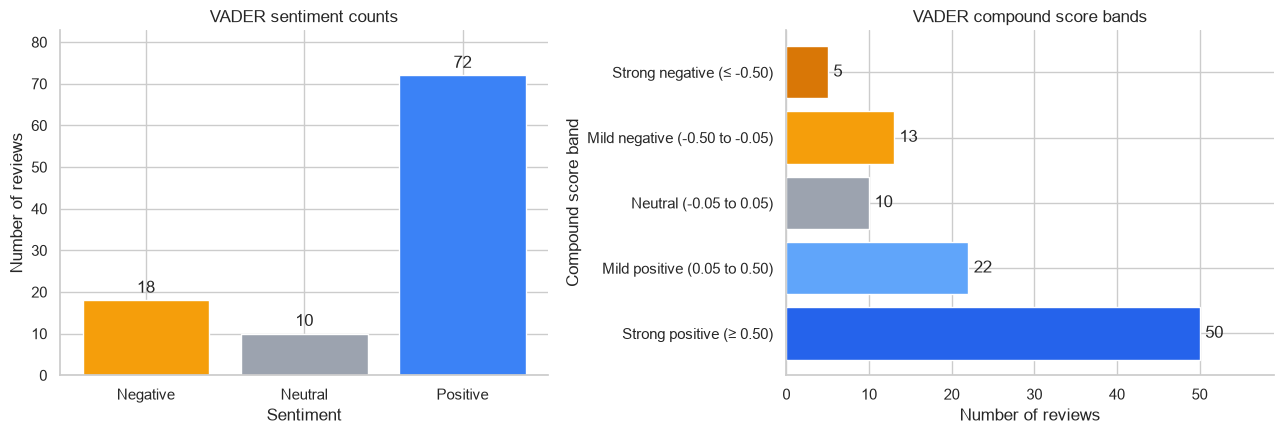

In [5]:
# 左图展示三分类数量；右图把 compound 分数细分为五个区间，并显示每个区间的数量。
vader_counts = ordered_sentiment_counts(reviews_clean["vader_sentiment"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].bar(
    vader_counts.index,
    vader_counts.values,
    color=[SENTIMENT_COLORS[label] for label in vader_counts.index],
)
axes[0].bar_label(bars, padding=3)
axes[0].set(title="VADER sentiment counts", xlabel="Sentiment", ylabel="Number of reviews")
axes[0].set_ylim(0, max(vader_counts.max() * 1.15, 1))

def vader_score_band(compound: float) -> str:
    """将 compound 分数划分为便于阅读的五个强度区间。

    -0.05 和 0.05 仍严格采用 VADER 的三分类阈值；
    额外使用 -0.50 和 0.50 区分较弱与较强的情绪。
    """
    if compound <= -0.50:
        return "Strong negative (≤ -0.50)"
    if compound <= VADER_NEGATIVE_THRESHOLD:
        return "Mild negative (-0.50 to -0.05)"
    if compound < VADER_POSITIVE_THRESHOLD:
        return "Neutral (-0.05 to 0.05)"
    if compound < 0.50:
        return "Mild positive (0.05 to 0.50)"
    return "Strong positive (≥ 0.50)"

score_band_order = [
    "Strong negative (≤ -0.50)",
    "Mild negative (-0.50 to -0.05)",
    "Neutral (-0.05 to 0.05)",
    "Mild positive (0.05 to 0.50)",
    "Strong positive (≥ 0.50)",
]
score_band_counts = (
    reviews_clean["vader_compound"]
    .apply(vader_score_band)
    .value_counts()
    .reindex(score_band_order, fill_value=0)
)
score_band_bars = axes[1].barh(
    score_band_counts.index,
    score_band_counts.values,
    color=["#D97706", "#F59E0B", "#9CA3AF", "#60A5FA", "#2563EB"],
)
# 直接标出每个分数区间的评论数量，避免从刻度线估算。
axes[1].bar_label(score_band_bars, padding=4)
axes[1].set(
    title="VADER compound score bands",
    xlabel="Number of reviews",
    ylabel="Compound score band",
)
axes[1].set_xlim(0, max(score_band_counts.max() * 1.18, 1))
axes[1].invert_yaxis()
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

## 5. 使用 Transformers 进行情感分析

这里使用成熟的 `nlptown/bert-base-multilingual-uncased-sentiment`。它基于多语言 BERT，并在英语、荷兰语、德语、法语、西班牙语和意大利语的商品评论上完成微调，输出 `1 star` 到 `5 stars`。这与当前书评数据的 1–5 星结构更接近。

为了与 VADER 对比，将 1–2 星映射为 `Negative`、3 星映射为 `Neutral`、4–5 星映射为 `Positive`。首次运行需要下载约 670 MB 模型权重，之后会使用本地缓存。

In [6]:
# pipeline("sentiment-analysis") 封装了分词、BERT 推理和标签输出。
# device=-1 明确使用 CPU；有兼容 CUDA 的 GPU 时可改为 device=0。
transformer_analyzer = pipeline(
    "sentiment-analysis",
    model=TRANSFORMER_MODEL,
    device=-1,
)

# 批量推理比逐行调用更高效；truncation 防止超长评论超过 BERT 的长度限制。
transformer_predictions = transformer_analyzer(
    reviews_clean["clean_text"].tolist(),
    batch_size=TRANSFORMER_BATCH_SIZE,
    truncation=True,
    max_length=TRANSFORMER_MAX_LENGTH,
)

if len(transformer_predictions) != len(reviews_clean):
    raise RuntimeError("Transformer 返回数量与输入评论数量不一致。")

def parse_transformer_star(label: str) -> int:
    """严格解析模型的 '1 star'–'5 stars' 标签。

    若未来更换模型且标签格式发生变化，立即抛出含原始标签的错误，
    避免悄悄生成错误情感分类。
    """
    try:
        stars = int(label.split(maxsplit=1)[0])
    except (ValueError, IndexError) as error:
        raise ValueError(f"无法解析 Transformer 标签: {label!r}") from error
    if not 1 <= stars <= 5:
        raise ValueError(f"Transformer 星级超出 1–5: {label!r}")
    return stars

# 保留原始标签，便于调试模型输出和核对映射规则。
reviews_clean["transformer_raw_label"] = [item["label"] for item in transformer_predictions]
reviews_clean["transformer_star"] = reviews_clean["transformer_raw_label"].apply(parse_transformer_star)
reviews_clean["transformer_sentiment"] = reviews_clean["transformer_star"].apply(star_to_sentiment)
reviews_clean["transformer_confidence"] = [item["score"] for item in transformer_predictions]

transformer_columns = [
    TEXT_COLUMN, "clean_text", "transformer_star",
    "transformer_sentiment", "transformer_confidence",
]
display(reviews_clean[transformer_columns].head(10))
display(ordered_sentiment_counts(reviews_clean["transformer_sentiment"]).rename("count").to_frame())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,reviewText,clean_text,transformer_star,transformer_sentiment,transformer_confidence
0,Clean and funny. A bit busy with all the diffe...,clean and funny a bit busy with all the differ...,4,Positive,0.755495
1,Alex a sexy hot cop and the PhD candidate. Wha...,alex a sexy hot cop and the phd candidate what...,5,Positive,0.719171
2,Good thing that this is a free story. I read i...,good thing that this is a free story i read it...,3,Neutral,0.325741
3,"Action, action, action! Equipment keeps gettin...",action action action equipment keeps getting b...,3,Neutral,0.397174
4,this was hands down the worse book i have ever...,this was hands down the worse book i have ever...,1,Negative,0.899459
5,"Great book packed full with fast cars , crazy ...",great book packed full with fast cars crazy ho...,5,Positive,0.826882
6,I enjoyed the reader's digest very much. If I ...,i enjoyed the readers digest very much if i co...,4,Positive,0.490474
7,This series has been good and I look forward t...,this series has been good and i look forward t...,5,Positive,0.454317
8,I just could not get into this book.I all ways...,i just could not get into this booki all ways ...,1,Negative,0.673653
9,it was good to see where Dan and Elle was. And...,it was good to see where dan and elle was and ...,4,Positive,0.499559


,count
transformer_sentiment,
Negative,30
Neutral,22
Positive,48


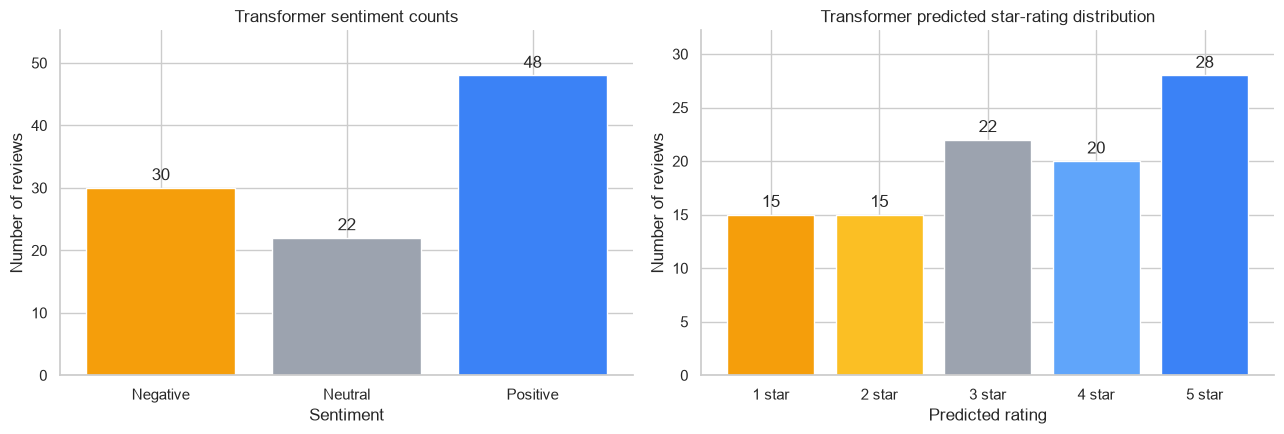

In [7]:
# 左图概括三类情绪数量；右图进一步展示模型预测的 1～5 星评分数量。
transformer_counts = ordered_sentiment_counts(reviews_clean["transformer_sentiment"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].bar(
    transformer_counts.index,
    transformer_counts.values,
    color=[SENTIMENT_COLORS[label] for label in transformer_counts.index],
)
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Transformer sentiment counts", xlabel="Sentiment", ylabel="Number of reviews")
axes[0].set_ylim(0, max(transformer_counts.max() * 1.15, 1))

# 星级是离散值，因此使用柱状图比连续型直方图更准确，也更容易看出哪种评分最多。
star_order = list(range(1, 6))
transformer_star_counts = (
    reviews_clean["transformer_star"]
    .value_counts()
    .reindex(star_order, fill_value=0)
)
star_bars = axes[1].bar(
    star_order,
    transformer_star_counts.values,
    color=["#F59E0B", "#FBBF24", "#9CA3AF", "#60A5FA", "#3B82F6"],
)
# 在柱顶直接标注评论数量，避免仅凭坐标轴估算。
axes[1].bar_label(star_bars, padding=3)
axes[1].set(
    title="Transformer predicted star-rating distribution",
    xlabel="Predicted rating",
    ylabel="Number of reviews",
)
axes[1].set_xticks(star_order, [f"{star} star" for star in star_order])
axes[1].set_ylim(0, max(transformer_star_counts.max() * 1.15, 1))
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

## 6. 对比模型结果

为了获得一个直观参照，将 1–2 星映射为负面、3 星映射为中性、4–5 星映射为正面。评分来自数据集，而 VADER 和 Transformers 预测只使用 `clean_text`。堆叠条形图比较三种来源的类别占比。

,Negative,Neutral,Positive
Human rating,37,17,46
VADER,18,10,72
Transformer,30,22,48


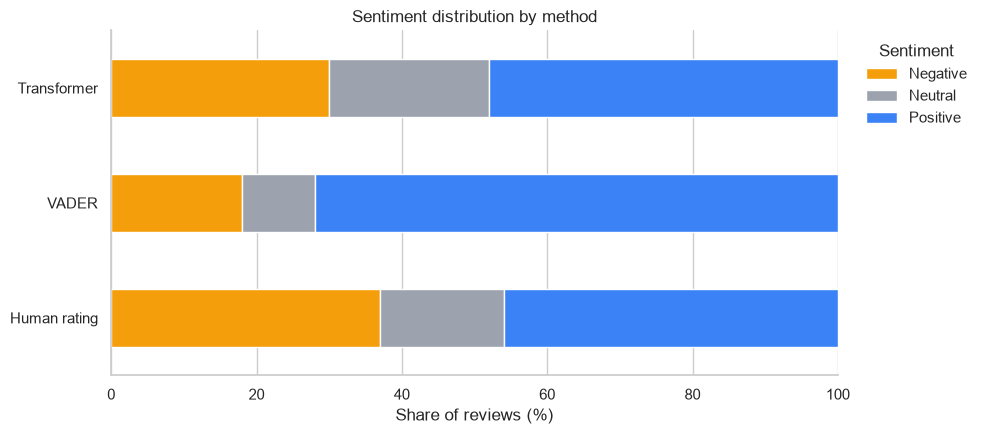

VADER vs rating agreement (3 classes): 64.0%
Transformer vs rating agreement (3 classes): 80.0%


In [8]:
# 人工评分与 Transformer 预测星级使用同一个映射函数。
reviews_clean["rating_sentiment"] = reviews_clean[RATING_COLUMN].apply(star_to_sentiment)

distribution_counts = pd.DataFrame(
    {
        "Human rating": reviews_clean["rating_sentiment"].value_counts(),
        "VADER": reviews_clean["vader_sentiment"].value_counts(),
        "Transformer": reviews_clean["transformer_sentiment"].value_counts(),
    }
).T.reindex(columns=SENTIMENT_ORDER, fill_value=0).fillna(0).astype(int)
distribution_percent = distribution_counts.div(distribution_counts.sum(axis=1), axis=0) * 100
display(distribution_counts)

ax = distribution_percent.plot(
    kind="barh", stacked=True, figsize=(10, 4.5),
    color=[SENTIMENT_COLORS[label] for label in SENTIMENT_ORDER],
)
ax.set(title="Sentiment distribution by method", xlabel="Share of reviews (%)", ylabel="")
ax.set_xlim(0, 100)
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

# 输出简单一致率作为学习参考；它不是完整的模型评估。
vader_agreement = (reviews_clean["vader_sentiment"] == reviews_clean["rating_sentiment"]).mean()
transformer_agreement = (reviews_clean["transformer_sentiment"] == reviews_clean["rating_sentiment"]).mean()
print(f"VADER vs rating agreement (3 classes): {vader_agreement:.1%}")
print(f"Transformer vs rating agreement (3 classes): {transformer_agreement:.1%}")

## 7. 结果小结与注意事项

### 为什么选择这个 Transformer 模型

- 它是完整的 BERT-base 模型，不是为了测试或演示而缩小的 tiny 随机模型。
- 它在商品评论数据上训练，比主要面向推文或金融文本的模型更接近书评场景。
- 它原生输出 1–5 星，因此可以合理保留 3 星对应的 `Neutral`，无需用低置信度伪造中性。
- 它支持六种语言；当前数据为英文，正好属于其训练语言范围。

### 本次 100 条评论的实测结果

- 人工星级映射：负面 37 条、中性 17 条、正面 46 条。
- VADER：负面 18 条、中性 10 条、正面 72 条；与人工星级三分类一致率为 64.0%。
- 成熟 Transformer：负面 30 条、中性 22 条、正面 48 条；与人工星级三分类一致率为 80.0%。

### 解读限制

- VADER 是基于词典和规则的方法，速度快，并能提供连续的 `compound` 分数。
- Transformer 的三分类来自预测星级映射：1–2 星为负面、3 星为中性、4–5 星为正面。
- 模型置信度表示模型对自身预测的确定程度，不等于预测一定正确。
- 星级评分只是近似参照；评论文字与用户打分可能不完全一致。
- 按需求进行的小写化和去标点会删除 VADER 可利用的强调信号，正式项目应对比原文与清洗文本。
- 若用于正式评估，应另外准备人工标注测试集，并计算 precision、recall、F1 和混淆矩阵。